Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
sales_data = pd.read_csv('retail_sales_dataset.csv')

sales_data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [17]:
sales_data.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [18]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [19]:
sales_data.shape

(1000, 9)

In [20]:
sales_data.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [24]:
sales_data.duplicated().sum()

np.int64(0)

In [25]:
sales_data=sales_data.drop_duplicates()

In [29]:
sales_data.describe()


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [35]:
sales_data['Total Amount'].mean()

np.float64(456.0)

In [30]:
sales_data['Total Amount'].median()

135.0

In [34]:
sales_data['Total Amount'].mode()

,Total Amount
0,50


In [36]:
sales_data['Total Amount'].std()

559.997631555123

Time Series Analysis: Analyze sales trends over time using time series techniques.

In [54]:

sales_data = pd.read_csv('retail_sales_dataset.csv')

sales_data['Date'] = pd.to_datetime(sales_data['Date'])

monthly_sales = sales_data.groupby(
    sales_data['Date'].dt.to_period('M')
)['Total Amount'].sum()

print(monthly_sales)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


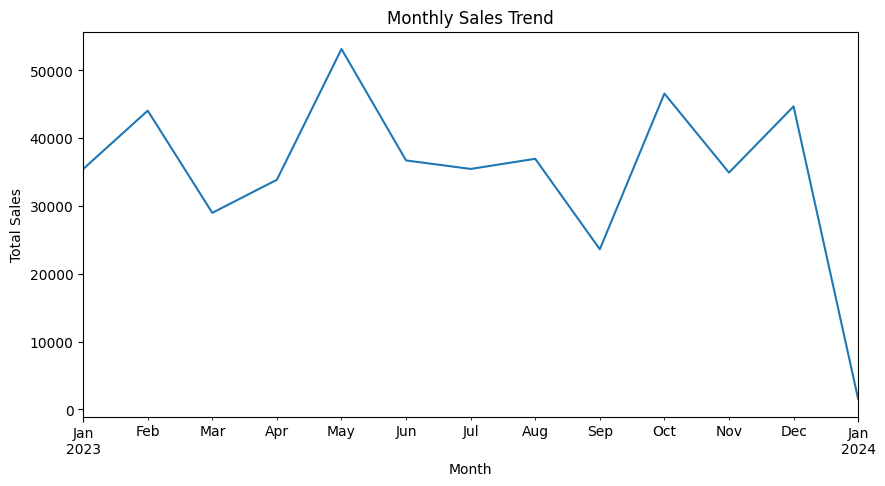

In [55]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

In [56]:
daily_sales = sales_data.groupby(
    'Date'
)['Total Amount'].sum()

print(daily_sales)

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
              ... 
2023-12-27     700
2023-12-28    2075
2023-12-29    3400
2023-12-31      50
2024-01-01    1530
Name: Total Amount, Length: 345, dtype: int64


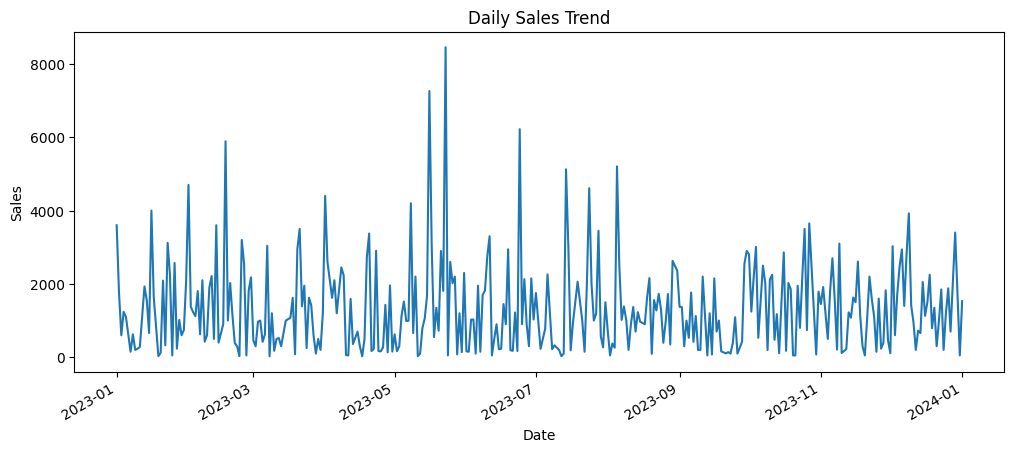

Highest Sales Month: 2023-05
Maximum Monthly Sales: 53150
Lowest Sales Month: 2024-01
Minimum Monthly Sales: 1530


In [66]:
daily_sales.plot(figsize=(12,5))

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

print('Highest Sales Month:',monthly_sales.idxmax())
print('Maximum Monthly Sales:',monthly_sales.max())

print('Lowest Sales Month:',monthly_sales.idxmin())
print('Minimum Monthly Sales:',monthly_sales.min())

Customer and Product Analysis: Analyze customer demographics and purchasing behavior.

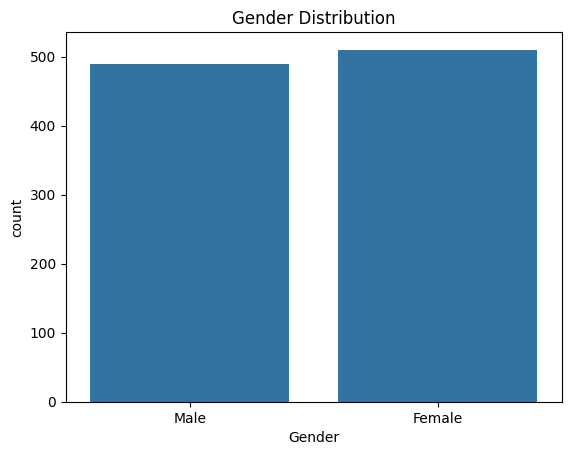

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Gender',
    data=sales_data
)

plt.title('Gender Distribution')

plt.show()

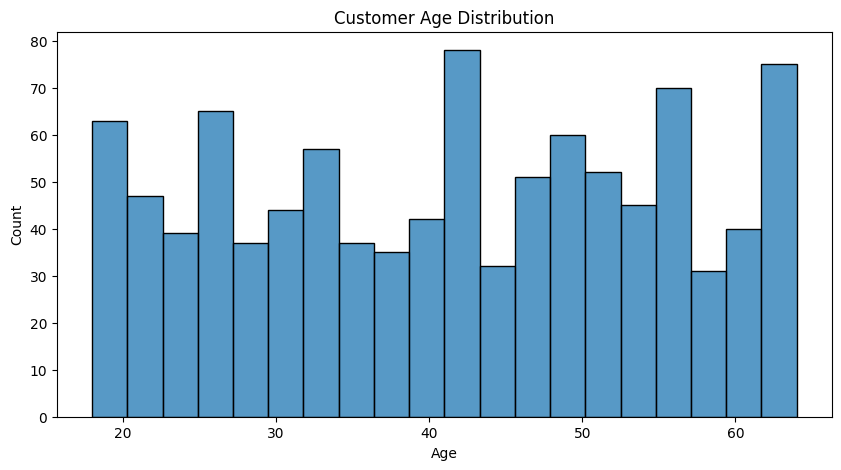

In [68]:
plt.figure(figsize=(10,5))

sns.histplot(
    sales_data['Age'],
    bins=20
)

plt.title('Customer Age Distribution')

plt.xlabel('Age')

plt.show()

In [69]:
top_customers = sales_data.groupby(
    'Customer ID'
)['Total Amount'].sum().sort_values(
    ascending=False
).head(10)

print(top_customers)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64


In [70]:
category_sales = sales_data.groupby(
    'Product Category'
)['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


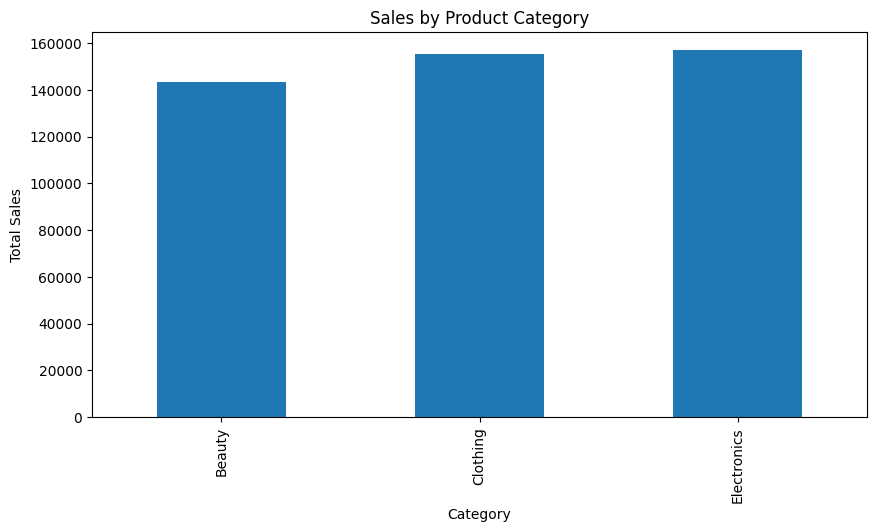

In [71]:
category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Sales by Product Category')

plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [72]:
quantity_data = sales_data.groupby(
    'Product Category'
)['Quantity'].sum()

print(quantity_data)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


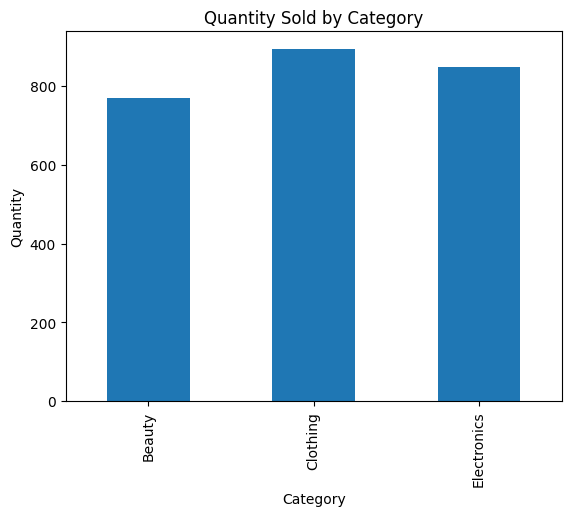

In [73]:
quantity_data.plot(
    kind='bar'
)

plt.title('Quantity Sold by Category')

plt.xlabel('Category')
plt.ylabel('Quantity')

plt.show()

Visualization: Present insights through bar charts, line plots, and heatmaps.

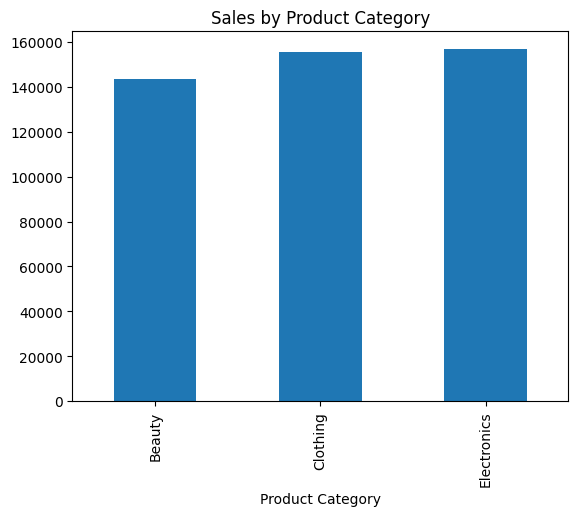

In [74]:
category_sales = sales_data.groupby(
    'Product Category'
)['Total Amount'].sum()

category_sales.plot(kind='bar')

plt.title('Sales by Product Category')

plt.show()

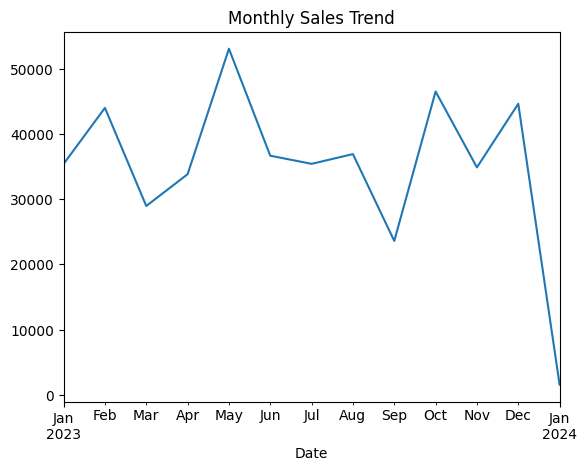

In [75]:
sales_data['Date'] = pd.to_datetime(
    sales_data['Date']
)

monthly_sales = sales_data.groupby(
    sales_data['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales.plot()

plt.title('Monthly Sales Trend')

plt.show()

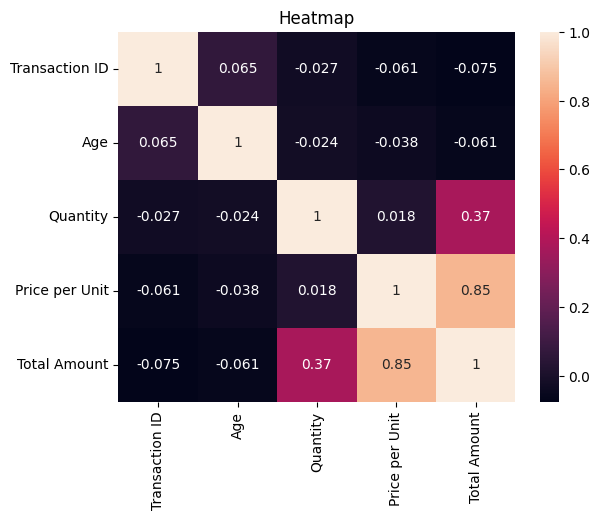

In [76]:
correlation = sales_data.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True
)

plt.title('Heatmap')

plt.show()

Recommendations:

Based on the Exploratory Data Analysis (EDA) performed on the retail sales dataset, the following recommendations are suggested for improving business performance:

1.Increase inventory for product categories with high sales demand to avoid stock shortages.

2.Provide discounts and promotional offers on low-selling products to improve their sales.

3.Focus marketing campaigns on young adult customers, as they contribute significantly to total purchases.

4.Introduce loyalty programs and special rewards for repeat customers to improve customer retention.

5.Increase advertising and promotional activities during high-sales months to maximize revenue.

6.Improve customer service and shopping experience to increase customer satisfaction and repeat purchases.

7.Expand popular product categories by adding more product varieties and options.

8.Use monthly sales trends for better inventory management and future sales planning.

9.Analyze customer purchasing behavior regularly to understand changing customer preferences.

10.Utilize sales data for future forecasting and strategic business decision-making.